# The Six Assumptions of Linear Regression — checked one at a time

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · 05 Feature Engineering · **▶ 06 Regression** · 07 Model Prep · 08 Case Studies

`06_Statistics_and_Regression/02_linear_regression_assumptions_step_by_step.ipynb`

---

### In one paragraph (no jargon)

Linear regression will produce coefficients, an R² and a p-value for absolutely any data you give it. Whether those numbers mean anything depends on six assumptions. Checking them is not a formality — it's the difference between a model you can act on and a set of numbers that look authoritative and are wrong. This notebook works through all six on the advertising dataset: what each one means, how to test it graphically and statistically, and what to do when it fails.

### After this notebook you can

- State all six assumptions and why each one matters
- Check each with both a plot and a formal test
- Read a residual plot — the single most informative diagnostic there is
- Interpret Goldfeld-Quandt, Durbin-Watson and VIF, and say what to do when they fail


### What's inside

1. Setup and the data
2. 1. Linearity
3. Fitting the model
4. 2. Mean of residuals is zero
5. 3. Homoscedasticity (equal error spread)
6. 4. Normality of residuals
7. 5. No autocorrelation
8. 6. No multicollinearity
9. Summary table of all six
10. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Dependent variable (y)** | The thing you're trying to predict or explain. Sales, price, mpg. |
| **Independent variable (X)** | The things you're using to predict it. Also called features or predictors. |
| **Coefficient** | "If this predictor goes up by 1, y changes by this much, holding everything else fixed." |
| **Intercept** | The predicted y when every predictor is zero. Often not meaningful on its own. |
| **Residual** | Actual minus predicted. The bit the model got wrong, for one row. |
| **R²** | The share of the variation in y the model explains. 0 = none, 1 = all. |
| **p-value** | "If this predictor really had no effect, how likely is a result this strong by chance?" Below 0.05 is the usual threshold for taking it seriously. |
| **Homoscedasticity** | The errors are equally spread across the whole range. The opposite is heteroscedasticity. |
| **Autocorrelation** | Today's error is related to yesterday's — common in time series, a problem for the standard formulas. |
| **Multicollinearity** | Two predictors carry nearly the same information, so the model can't tell which deserves the credit. |
| **VIF** | Variance Inflation Factor — the standard multicollinearity score. Above 5 is a warning; above 10 is a problem. |
| **OLS** | Ordinary Least Squares — the standard way of fitting a straight line by minimising squared errors. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
import statsmodels.api as sm
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_advertisement():
    """Exact copy of advertisement.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Unnamed: 0,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,14.2,1.0,4.8
10,199.8,12.5,21.2,10.6
11,66.1,5.8,24.2,8.6
12,214.7,24.0,4.0,17.4
13,23.8,35.1,65.9,9.2
14,97.5,7.6,7.2,9.7
15,204.1,32.9,46.0,19.0
16,195.4,47.7,52.9,22.4
17,67.8,36.6,16.0,12.5
18,281.4,39.6,55.8,24.4
19,69.2,20.5,18.3,11.3
20,147.3,23.9,19.1,14.6
21,1200.0,27.7,53.4,18.0
22,237.4,5.1,23.5,12.5
23,13.2,15.9,49.6,5.6
24,228.3,16.9,26.2,15.5
25,62.3,12.6,18.3,9.7
26,0.0,3.5,19.5,12.0
27,142.9,29.3,12.6,15.0
28,240.1,16.7,22.9,15.9
29,248.8,27.1,22.9,18.9
30,70.6,16.0,200.0,10.5
31,292.9,28.3,43.2,21.4
32,112.9,17.4,38.6,11.9
33,97.2,16.9,30.0,9.6
34,265.6,20.0,0.3,17.4
35,95.7,15.0,7.4,9.5
36,290.7,12.5,8.5,12.8
37,266.9,21.0,5.0,25.4
38,74.7,49.4,45.7,14.7
39,43.1,26.7,85.0,10.1
40,228.0,37.7,32.0,21.5
41,202.5,22.3,31.6,16.6
42,177.0,33.4,38.7,17.1
43,293.6,27.7,1.8,20.7
44,206.9,8.4,26.4,12.9
45,25.1,25.7,43.3,8.5
46,175.1,22.5,31.5,14.9
47,89.7,9.9,35.7,10.6
48,239.9,41.5,18.5,23.2
49,227.2,15.8,49.9,14.8
50,66.9,11.7,36.8,9.7
51,199.8,13.5,34.6,11.4
52,100.4,9.6,85.0,10.7
53,216.4,41.7,39.6,22.6
54,182.6,46.2,58.7,21.2
55,262.7,28.8,15.9,20.2
56,198.9,49.4,60.0,23.7
57,7.3,28.1,41.4,5.5
58,136.2,19.2,16.6,13.2
59,,49.6,0.0,23.8
60,210.7,29.5,9.3,18.4
61,53.5,14.3,21.4,8.1
62,261.3,42.7,54.7,24.2
63,239.3,15.5,27.3,15.7
64,102.7,29.6,8.4,14.0
65,131.1,42.8,28.9,18.0
66,69.0,9.3,0.9,9.3
67,31.5,24.6,2.2,9.5
68,139.3,14.5,10.2,13.4
69,237.4,27.5,11.0,18.9
70,216.8,43.9,27.2,22.3
71,199.1,30.6,38.7,18.3
72,109.8,14.3,31.7,12.4
73,26.8,33.0,98.0,8.8
74,129.4,5.7,31.3,11.0
75,213.4,24.6,13.1,17.0
76,16.9,43.7,89.4,8.7
77,27.5,11.6,20.7,6.9
78,120.5,28.5,14.2,14.2
79,5.4,29.9,9.4,5.3
80,1125.0,7.7,23.1,11.0
81,76.4,26.7,22.3,11.8
82,852.0,4.1,36.9,12.3
83,75.3,20.3,32.5,11.3
84,68.4,44.5,35.6,13.6
85,213.5,43.0,175.0,21.7
86,193.2,18.4,65.7,15.2
87,76.3,27.5,16.0,12.0
88,110.7,40.6,63.2,16.0
89,88.3,25.5,73.4,12.9
90,109.8,47.8,51.4,16.7
91,134.3,4.9,9.3,11.2
92,28.6,12.5,33.0,7.3
93,217.7,33.5,59.0,19.4
94,250.9,36.5,72.3,22.2
95,107.4,14.0,10.9,11.5
96,163.3,31.6,52.9,16.9
97,197.6,3.5,5.9,11.7
98,184.9,21.0,22.0,15.5
99,289.7,42.3,51.2,25.4
100,135.2,41.7,45.9,17.2
101,222.4,4.3,49.8,11.7
102,296.4,36.3,100.9,23.8
103,280.2,10.1,21.4,14.8
104,187.9,17.2,17.9,14.7
105,238.2,34.3,5.3,20.7
106,137.9,46.4,59.0,19.2
107,25.0,11.0,29.7,7.2
108,90.4,12.5,23.2,8.7
109,13.1,13.5,25.6,5.3
110,255.4,26.9,5.5,19.8
111,225.8,8.2,56.5,13.4
112,241.7,38.0,23.2,21.8
113,175.7,15.4,2.4,14.1
114,209.6,20.6,10.7,15.9
115,78.2,46.8,34.5,14.6
116,75.1,35.0,52.7,12.6
117,139.2,14.3,25.6,12.2
118,76.4,10.8,14.8,9.4
119,125.7,36.9,79.2,15.9
120,19.4,16.0,22.3,6.6
121,141.3,26.8,146.0,15.5
122,18.8,21.7,50.4,7.0
123,224.0,12.5,15.6,11.6
124,123.1,34.6,12.4,15.2
125,229.5,32.3,74.2,19.7
126,87.2,11.8,25.9,10.6
127,7.8,38.9,50.6,6666.0
128,80.2,25.0,0.0,8.8
129,220.3,49.0,3.2,24.7
130,59.6,12.0,43.1,9.7
131,0.7,39.6,8.7,1.6
132,265.2,15.0,43.0,12.7
133,8.4,27.2,2.1,5.7
134,219.8,33.5,45.1,19.6
135,36.9,38.6,65.6,10.8
136,48.3,47.0,8.5,11.6
137,25.6,39.0,9.3,9.5
138,273.7,28.9,59.7,20.8
139,43.0,25.9,20.5,9.6
140,925.0,43.9,1.7,20.7
141,73.4,17.0,12.9,10.9
142,193.7,35.4,75.6,19.2
143,220.5,33.2,37.9,20.1
144,104.6,5.7,34.4,10.4
145,96.2,14.8,38.9,11.4
146,140.3,15.2,9.0,10.3
147,240.1,7.3,8.7,13.2
148,243.2,49.0,44.3,25.4
149,38.0,40.3,11.9,10.9
150,44.7,25.8,20.6,10.1
151,280.7,13.9,37.0,16.1
152,,8.4,48.7,11.6
153,197.6,23.3,14.2,16.6
154,171.3,39.7,37.7,19.0
155,187.8,21.1,9.5,15.6
156,4.1,11.6,5.7,3.2
157,93.9,43.5,50.5,15.3
158,149.8,39.5,24.3,10.1
159,11.7,36.9,45.2,7.3
160,131.7,18.4,34.6,12.9
161,172.5,18.1,30.7,14.4
162,85.7,35.8,2.0,13.3
163,188.4,959.0,25.6,14.9
164,163.5,36.8,7.4,18.0
165,117.2,14.7,5.4,11.9
166,234.5,22.5,84.8,11.9
167,17.9,37.6,21.6,8.0
168,206.8,5.2,19.4,12.2
169,215.4,23.6,57.6,17.1
170,284.3,10.6,6.4,15.0
171,50.0,11.6,18.4,8.4
172,164.5,20.9,47.4,14.5
173,19.6,20.1,17.0,0.0
174,168.4,7.1,12.8,11.7
175,222.4,21.5,13.1,11.5
176,276.9,48.9,41.8,27.0
177,248.4,30.2,20.3,20.2
178,170.2,7.8,35.2,11.7
179,276.7,15.5,23.7,11.8
180,165.6,10.0,17.6,12.6
181,156.6,12.6,8.3,10.5
182,218.5,25.0,27.4,12.2
183,1000.32,22.0,29.7,8.7
184,287.6,589.0,71.8,26.2
185,253.8,21.3,30.0,17.6
186,156.0,45.1,19.6,22.6
187,139.5,14.5,26.6,10.3
188,191.1,28.7,18.2,17.3
189,286.0,13.9,3.7,15.9
190,18.7,12.1,23.4,6.7
191,39.5,41.1,5.8,10.8
192,545.0,10.8,6.0,9.9
193,15.0,25.0,31.6,5.9
194,166.8,42.0,3.6,19.6
195,149.7,35.6,6.0,17.3
196,38.2,32.5,13.8,7.6
197,94.2,24.3,8.1,9.7
198,177.0,25.5,6.4,12.8
199,283.6,42.0,66.2,25.5
200,232.1,15.9,8.7,13.4"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


## assumptions of linear regression

### One of the most essential steps to take before applying linear regression and depending solely on accuracy scores is to check for these assumptions.


<br><a href="#linearity">1. Linearity</a>
<br><a href="#mean">2. Mean of Residuals</a>
<br><a href="#homo">3. Check for Homoscedasticity</a>
<br><a href="#normal">4. Check for Normality of error terms/residuals</a>
<br><a href="#auto">5. No autocorrelation of residuals</a>
<br><a href="#multico">6. No perfect multicollinearity</a>

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
sns.set_theme(context="notebook", palette="Spectral", style = 'darkgrid' ,font_scale = 1.5, color_codes=True)
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.pyplot as plt

In [3]:
ad_data = load_data('advertisement.csv', rebuild=rebuild_advertisement,index_col='Unnamed: 0')

Loaded 'advertisement.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets


In [4]:
# The file stores its columns in lower case ('radio', 'sales'). The cells below expect
# Title Case, so we standardise the names once, here, rather than editing every cell.
ad_data = ad_data.rename(columns={c: c.title() for c in ad_data.columns})
ad_data = ad_data.rename(columns={'Tv': 'TV'})

# This file also has two genuinely missing TV values. scikit-learn refuses to fit
# a model on data containing NaN, so they must be dealt with BEFORE modelling.
# With 2 blanks in 200 rows, dropping them costs 1% of the sample and avoids
# inventing values - the defensible choice here. (See 03_Data_Cleaning/01 for
# when imputation would be the better call.)
print('Missing values before cleaning:', ad_data.isnull().sum().sum())
ad_data = ad_data.dropna()
print(f'Rows after dropping: {len(ad_data)}')
print('Columns:', list(ad_data.columns))
ad_data.info()

Missing values before cleaning: 2
Rows after dropping: 198
Columns: ['TV', 'Radio', 'Newspaper', 'Sales']
<class 'pandas.DataFrame'>
Index: 198 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         198 non-null    float64
 1   Radio      198 non-null    float64
 2   Newspaper  198 non-null    float64
 3   Sales      198 non-null    float64
dtypes: float64(4)
memory usage: 7.7 KB


In [5]:
ad_data.describe()

,TV,Radio,Newspaper,Sales
count,198.000000,198.000000,198.000000,198.000000
mean,169.288485,32.814646,32.727778,47.580303
std,165.469295,78.363589,28.446171,472.767249
min,0.000000,3.500000,0.000000,0.000000
25%,73.725000,14.350000,12.650000,10.400000
50%,153.750000,24.800000,25.600000,12.900000
75%,222.400000,36.575000,45.575000,17.400000
max,1200.000000,959.000000,200.000000,6666.000000


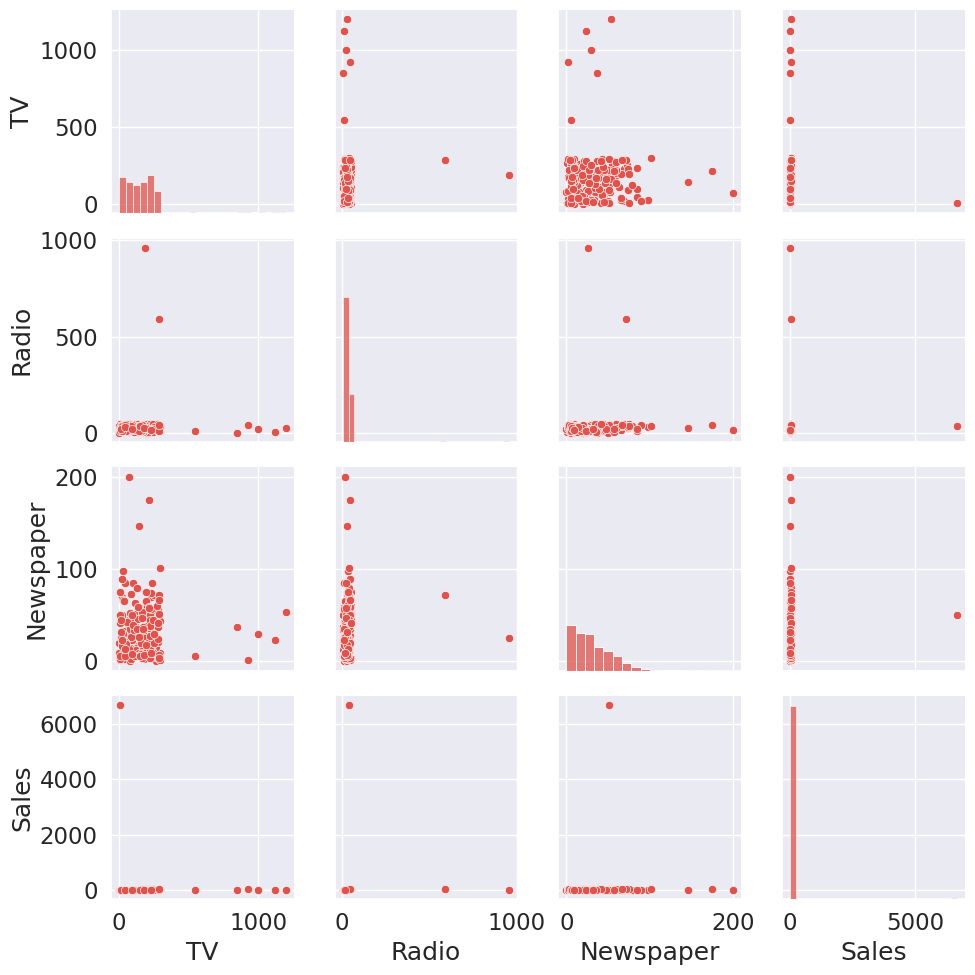

In [6]:
p = sns.pairplot(ad_data)

#  Assumptions for Linear Regression

## <a id="linearity">1. Linearity</a>

 ### Linear regression needs the relationship between the independent and dependent variables to be linear.  Let's use a pair plot to check the relation of independent variables with the Sales variable

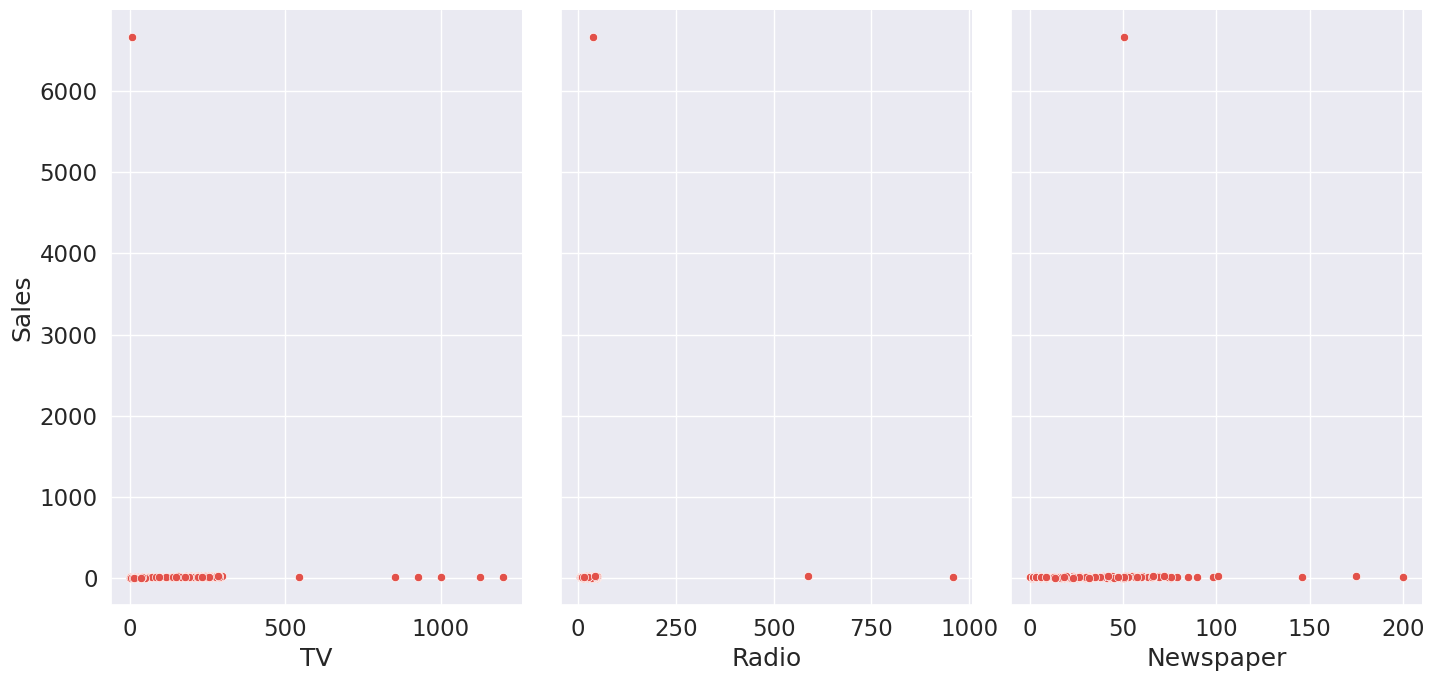

In [7]:
# visualize the relationship between the features and the response using scatterplots
p = sns.pairplot(ad_data, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', height=7, aspect=0.7)

### By looking at the plots we can see that with the Sales variable the none of the independent variables form an accurately linear shape but TV and Radio do still better than Newspaper which seems to hardly have any specific shape. So it shows that a linear regression fitting might not be the best model for it. A linear model might not be able to *efficiently* explain the data in terms of variability, prediction accuracy etc. 

A tip is to remember to always see the plots from where the dependent variable is on the y axis. Though it wouldn't vary the shape much but that's how linear regression's intuition is, to put the dependent variable as y and independents as x(s).

### Now rest of the assumptions require us to perform the regression before we can even check for them. So let's perform regression on it.

### Fitting the linear model

In [8]:
x = ad_data.drop(["Sales"],axis=1)
y = ad_data.Sales

In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(x)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state = 0,test_size=0.25)

In [11]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn import linear_model

regr = linear_model.LinearRegression()
regr.fit(X_train,y_train)
y_pred = regr.predict(X_train)

In [12]:
print("R squared: {}".format(r2_score(y_true=y_train,y_pred=y_pred)))

R squared: 0.009818710055885194


## <a id="mean">2. Mean of Residuals</a>

### Residuals as we know are the differences between the true value and the predicted value. One of the assumptions of linear regression is that the mean of the residuals should be zero. So let's find out.

In [13]:
residuals = y_train.values-y_pred
mean_residuals = np.mean(residuals)
print("Mean of Residuals {}".format(mean_residuals))

Mean of Residuals 0.0


### Very close to zero so all good here.

## <a id="homo">3. Check for Homoscedasticity</a>

### Homoscedasticity means that the residuals have equal or almost equal variance across the regression line. By plotting the error terms with predicted terms we can check that there should not be any pattern in the error terms.

## Imagine you’re predicting someone’s income based on their years of education.

### If your model’s errors (the differences between predicted and actual income) are about the same for people with 5, 10, or 15 years of education → ✅ Homoscedastic (good).

##### If the errors are small for people with little education but huge for people with a lot of education → ❌ Heteroscedastic (not good).

### Detecting heteroscedasticity! 
Graphical Method: Firstly do the regression analysis and then plot the error terms against the predicted values( Yi^). If there is a definite pattern (like linear or quadratic or funnel shaped) obtained from the scatter plot then heteroscedasticity is present.

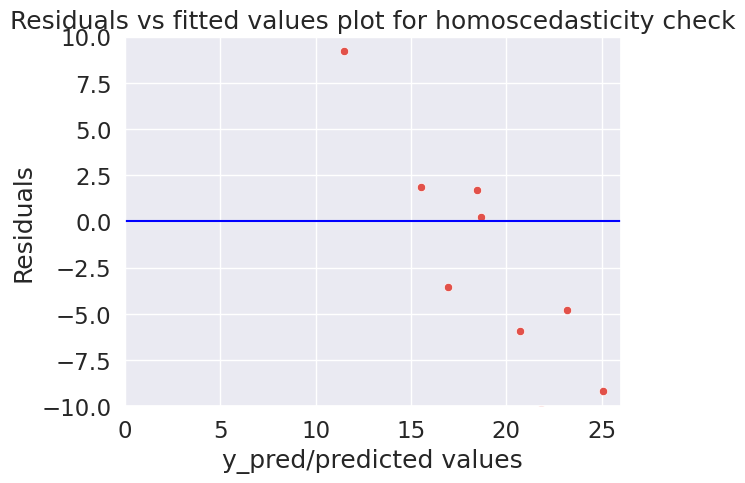

In [14]:
p = sns.scatterplot(x=y_pred,y=residuals)
plt.xlabel('y_pred/predicted values')
plt.ylabel('Residuals')
plt.ylim(-10,10)
plt.xlim(0,26)
p = sns.lineplot(x=[0,26],y=[0,0],color='blue')
p = plt.title('Residuals vs fitted values plot for homoscedasticity check')

### Now we will be applying tests. 
A tip is to keep in mind that if we want 95% confidence on our findings and tests then the p-value should be less than 0.05 to be able to reject the null hypothesis. Remember, a researcher or data scientist would always aim to reject the null hypothesis.

##  Goldfeld Quandt Test
Checking heteroscedasticity : Using Goldfeld Quandt we test for heteroscedasticity.
* Null Hypothesis: Error terms are homoscedastic
* Alternative Hypothesis: Error terms are heteroscedastic.

In [15]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(residuals, X_train)
lzip(name, test)

[('F statistic', np.float64(0.0035607166668004658)),
 ('p-value', np.float64(1.0))]

### Since p value is more than 0.05 in Goldfeld Quandt Test, we can't reject it's null hypothesis that error terms are homoscedastic. Good.

### Bartlett’s test tests the null hypothesis that all input samples are from populations with equal variances. 

In [16]:

from scipy.stats import bartlett

# Ensure X_train and residuals are 1-dimensional arrays
X_train = X_train.ravel()  # or X_train.flatten() if it's a NumPy array
residuals = residuals.ravel()  # or residuals.flatten()

# Now run Bartlett's test
test = bartlett(X_train, residuals)
print(test)

BartlettResult(statistic=np.float64(4706.348835970987), pvalue=np.float64(0.0))


### Since p value is quite less than 0.05 in Bartlett, it's null hypothesis that error terms are homoscedastic gets rejected, that's not good for a regression.

## <a id="normal">4. Check for Normality of error terms/residuals</a>

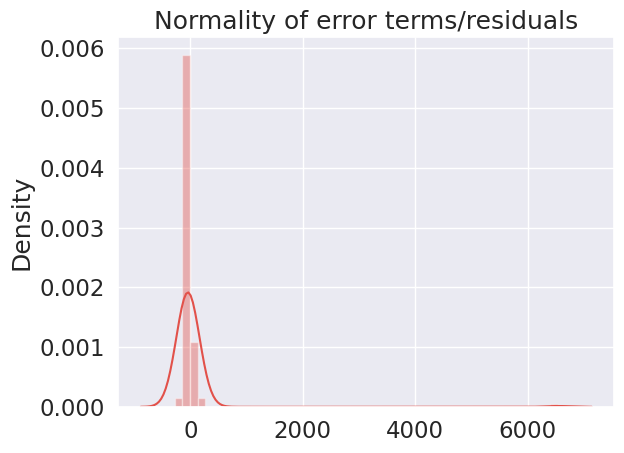

In [17]:
p = sns.distplot(residuals,kde=True)
p = plt.title('Normality of error terms/residuals')

### The residual terms are pretty much normally distributed for the number of test points we took. Remember the central limit theorem which says that as the sample size increases the distribution tends to be normal. A skew is also visible from the plot. It's very difficult to get perfect curves, distributions in real life data.

## <a id="auto">5. No autocorrelation of residuals</a>

### When the residuals are autocorrelated, it means that the current value is dependent of the previous (historic) values and that there is a definite unexplained pattern in the Y variable that shows up in the error terms. Though it is more evident in time series data.

#### In plain terms autocorrelation takes place when there's a pattern in the rows of the data. This is usual in time series data as there is a pattern of time for eg. Week of the day effect which is a very famous pattern seen in stock markets where people tend to buy stocks more towards the beginning of weekends and tend to sell more on Mondays. There's been great study about this phenomenon and it is still a matter of research as to what actual factors cause this trend.

### There should not be autocorrelation in the data so the error terms should not form any pattern.

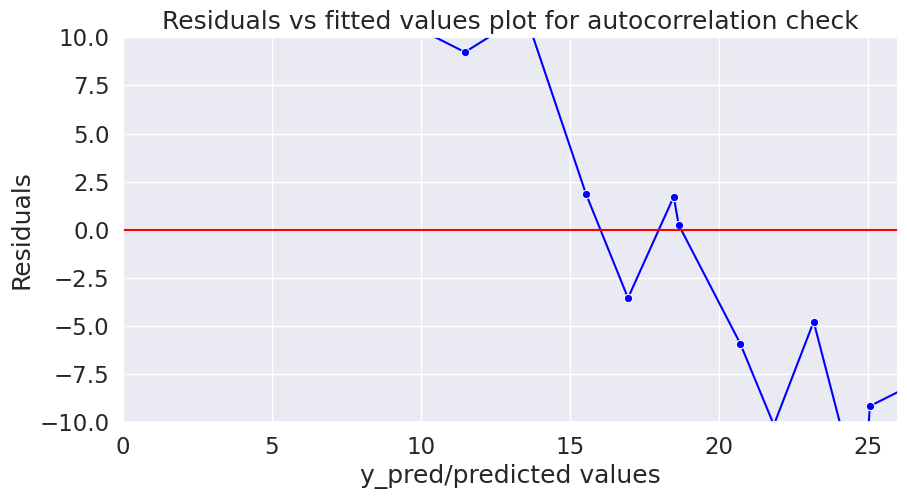

In [18]:
plt.figure(figsize=(10,5))
p = sns.lineplot(x=y_pred,y=residuals,marker='o',color='blue')
plt.xlabel('y_pred/predicted values')
plt.ylabel('Residuals')
plt.ylim(-10,10)
plt.xlim(0,26)
p = sns.lineplot(x=[0,26],y=[0,0],color='red')
p = plt.title('Residuals vs fitted values plot for autocorrelation check')

### Checking for autocorrelation To ensure the absence of autocorrelation we use Ljungbox test.
* Null Hypothesis: Autocorrelation is absent.
* Alternative Hypothesis: Autocorrelation is present.

In [19]:
from statsmodels.stats import diagnostic as diag

# Assume `residuals` is a 1D array or pandas Series of residuals
ljungbox_result = diag.acorr_ljungbox(residuals, lags=40)

# Print the result to understand its structure
print(ljungbox_result)

# Extract p-values from the result (they should be in the second column)
p_values = ljungbox_result['lb_pvalue']  # 'lb_pvalue' is the typical column name for p-values

# Find the minimum p-value
min_p_value = p_values.min()

print("Minimum p-value:", min_p_value)

     lb_stat  lb_pvalue
1   0.000698   0.978927
2   0.120757   0.941408
3   0.166778   0.982765
4   0.172569   0.996485
5   0.214347   0.998952
6   0.214620   0.999810
7   0.217719   0.999966
8   0.269903   0.999988
9   0.275630   0.999998
10  0.287577   1.000000
11  0.338769   1.000000
12  0.418912   1.000000
13  0.429671   1.000000
14  0.474313   1.000000
15  0.474351   1.000000
16  0.474439   1.000000
17  0.480618   1.000000
18  0.481717   1.000000
19  0.482508   1.000000
20  0.502102   1.000000
21  0.509898   1.000000
22  0.527536   1.000000
23  0.529614   1.000000
24  0.529621   1.000000
25  0.533045   1.000000
26  0.551492   1.000000
27  0.610214   1.000000
28  0.611202   1.000000
29  0.614529   1.000000
30  0.618522   1.000000
31  0.627591   1.000000
32  0.629976   1.000000
33  0.630167   1.000000
34  0.631231   1.000000
35  0.633379   1.000000
36  0.634065   1.000000
37  0.647700   1.000000
38  0.648915   1.000000
39  0.653535   1.000000
40  0.653551   1.000000
Minimum p-value:

### Since p value is less than 0.05 we reject the null hypothesis that error terms are not autocorrelated.

In [20]:
import statsmodels.api as sm

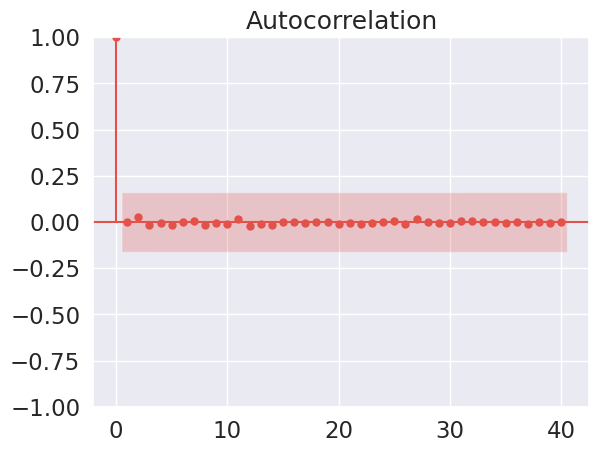

In [21]:
# autocorrelation
sm.graphics.tsa.plot_acf(residuals, lags=40)
plt.show()

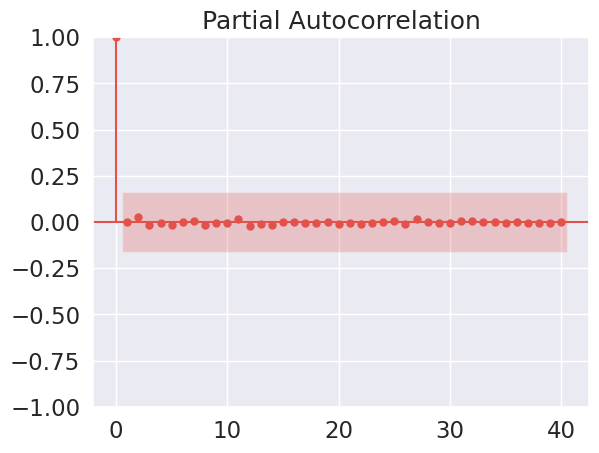

In [22]:
# partial autocorrelation
sm.graphics.tsa.plot_pacf(residuals, lags=40)
plt.show()

### The results show signs of autocorelation since there are spikes outside the red confidence interval region. This could be a factor of seasonality in the data.

## <a id="multico">6. No perfect multicollinearity</a>

### In regression, multicollinearity refers to the extent to which independent variables are correlated. Multicollinearity affects the coefficients and p-values, but it does not influence the predictions, precision of the predictions, and the goodness-of-fit statistics. If your primary goal is to make predictions, and you don’t need to understand the role of each independent variable, you don’t need to reduce severe multicollinearity.

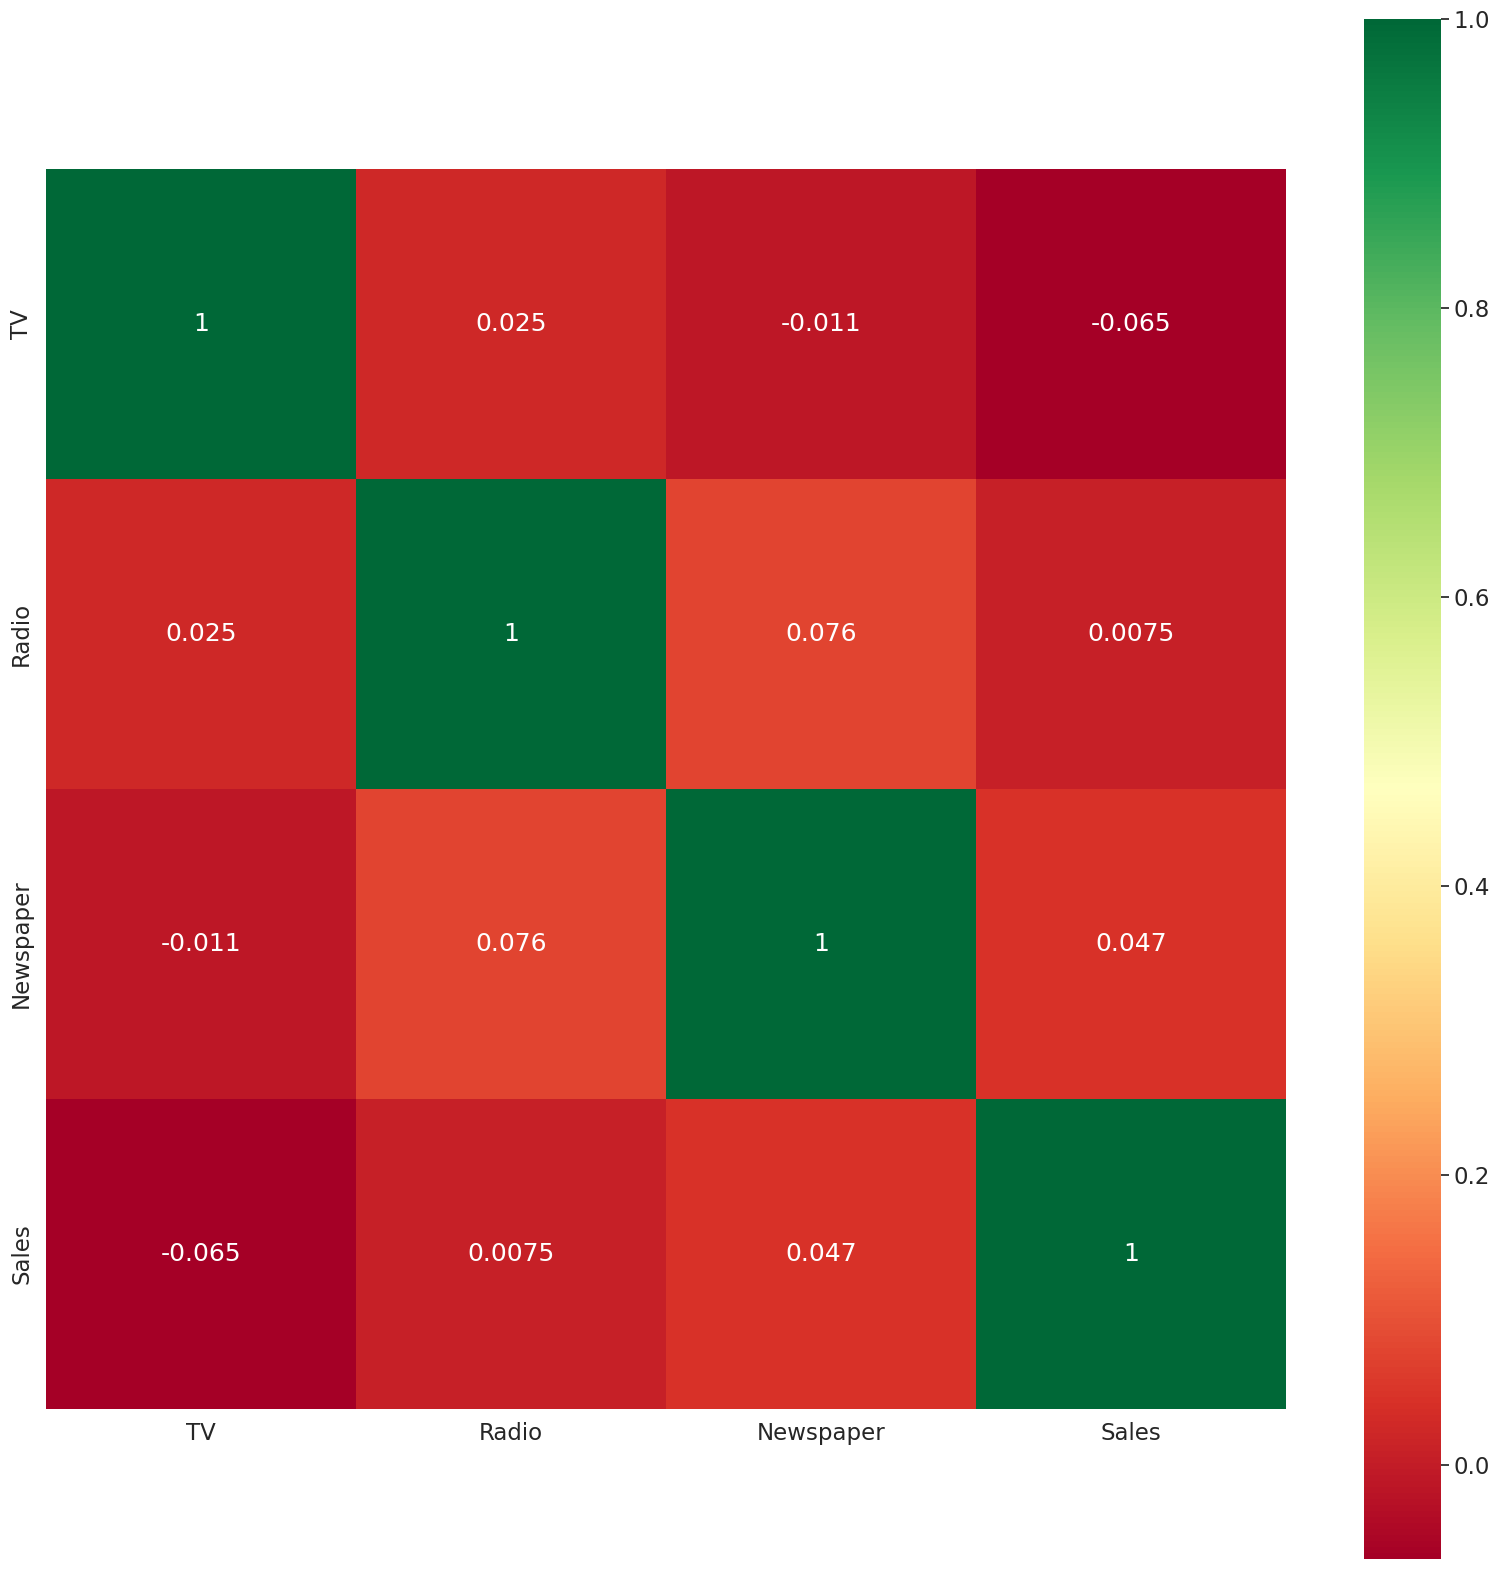

In [23]:
plt.figure(figsize=(20,20))
p=sns.heatmap(ad_data.corr(numeric_only=True), annot=True,cmap='RdYlGn',square=True)  

### Look for correlation of rows where the dependent variable (Sales in this case) is not involved because if a variable is correlated with the dependent variable then this would be a good sign for our model. Correlation within dependent variables is what we need to look for and avoid. This data doesn't contain perfect multicollinearity among independent variables. In case there was any then we would try to remove one of the correlated variables depending on which was more important to our regression model.

# So most of the major assumptions of Linear Regression are successfully through. Great! Since this was one of the simplest data sets it demonstrated the steps well.

---
## All six assumptions on one page

| # | Assumption | Plain English | How to check | If it fails |
|---|---|---|---|---|
| 1 | **Linearity** | y really does change in a straight line with each x | scatter/pair plot; residuals vs fitted | transform x or y, add a polynomial term |
| 2 | **Zero-mean residuals** | the model isn't systematically over- or under-predicting | `residuals.mean()` ≈ 0 | include an intercept (OLS with a constant guarantees this) |
| 3 | **Homoscedasticity** | errors are equally spread across the range | residuals vs fitted — look for a funnel; Goldfeld-Quandt or Breusch-Pagan test | robust (HC3) standard errors, weighted least squares, or transform y |
| 4 | **Normal residuals** | the errors follow a bell curve | histogram, Q-Q plot, Jarque-Bera test | usually fine in large samples (CLT); otherwise transform y or remove extreme outliers |
| 5 | **No autocorrelation** | one error doesn't predict the next | Durbin-Watson (≈2 is fine, <1 or >3 is a problem) | add a lag term, or use Newey-West standard errors |
| 6 | **No multicollinearity** | predictors aren't near-duplicates of each other | VIF (>5 warning, >10 problem); correlation heatmap | drop one of the pair, combine them, or use ridge regression |

**What actually breaks when each fails**

- **1 fails** → the coefficients are simply wrong. This is the serious one.
- **2 fails** → predictions are biased by a constant amount.
- **3 fails** → coefficients are still unbiased, but the **standard errors and p-values are wrong**, so you may declare something significant when it isn't.
- **4 fails** → p-values and confidence intervals are unreliable in small samples; largely harmless in large ones.
- **5 fails** → standard errors understated, so significance is overstated. Common in time series.
- **6 fails** → individual coefficients become unstable and hard to interpret; overall predictions are still fine.

**The one-line version for an exam:** *"I checked all six. Linearity and homoscedasticity were the binding
constraints here; I addressed them by log-transforming the predictor and reporting HC3 robust standard errors."*

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Fit with statsmodels | `sm.OLS(y, sm.add_constant(X)).fit()` |
| Full results table | `model.summary()` |
| Fit with sklearn | `LinearRegression().fit(X, y)` |
| Residuals | `y - model.predict(X)` |
| Mean of residuals | `residuals.mean()`  (should be ≈0) |
| Residual plot | `sns.scatterplot(x=y_pred, y=residuals)` |
| Q-Q plot | `statsmodels.graphics.gofplots.qqplot(resid, line='s')` |
| Goldfeld-Quandt | `sms.het_goldfeldquandt(resid, X)` |
| Breusch-Pagan | `sms.het_breuschpagan(resid, X)` |
| Durbin-Watson | `sms.durbin_watson(resid)` |
| VIF | `variance_inflation_factor(X.values, i)` |
| Pair plot | `sns.pairplot(df, x_vars=[…], y_vars='Sales')` |
| Robust standard errors | `model.get_robustcov_results(cov_type='HC3')` |

### Adapting this in the exam

- 'Check the assumptions of linear regression' → work through all six, one plot and one test each.
- 'Comment on the residual plot' → say whether you see a pattern (linearity problem), a funnel (heteroscedasticity), or formless scatter (all good).
- 'The p-value is 0.03, what does that mean?' → depends on the test's null hypothesis. For assumption tests, small p usually means the assumption is broken.

### Traps that cost marks

- A **low** p-value in a heteroscedasticity test means the assumption is **violated** — the null hypothesis is that everything is fine. Getting this backwards reverses your entire conclusion.
- `statsmodels` does **not** add an intercept for you. Always `sm.add_constant(X)` or your model is forced through the origin.
- Check assumptions on the residuals of the **fitted** model, not on the raw columns.
- Durbin-Watson near 2 is good; near 0 means positive autocorrelation, near 4 means negative.
- VIF needs a constant column included or the values come out wrong.
- A high R² proves nothing about the assumptions. A badly misspecified model can still have R² = 0.95.